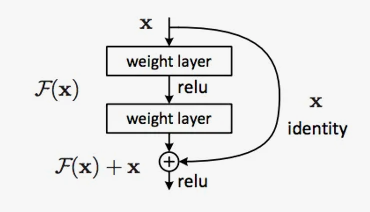

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
from tqdm import tqdm

In [2]:
# Настройка воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

In [3]:
# 1. Загрузка и подготовка данных Iris
iris = load_iris()
X = iris.data
y = iris.target

In [4]:
# Разделение на train/val/test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [5]:
# Нормализация
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [6]:
# Конвертация в тензоры PyTorch
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.LongTensor(y_val)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

In [7]:
# 2. Архитектура 1: Простая глубокая MLP
class SimpleDeepMLP(nn.Module):
    def __init__(self, input_size=4, hidden_sizes=[64, 64, 32, 32, 16], num_classes=3):
        super(SimpleDeepMLP, self).__init__()

        layers = []
        prev_size = input_size

        # Строим глубокую сеть
        for i, hidden_size in enumerate(hidden_sizes):
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.2))
            prev_size = hidden_size

        self.features = nn.Sequential(*layers)
        self.classifier = nn.Linear(prev_size, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [8]:
# 3. Архитектура 2: MLP с остаточными блоками (ResNet для полносвязных сетей)
class ResidualMLPBlock(nn.Module):
    def __init__(self, in_features, out_features, dropout=0.1):
        super(ResidualMLPBlock, self).__init__()

        # Основной путь блока
        self.linear1 = nn.Linear(in_features, out_features)
        self.bn1 = nn.BatchNorm1d(out_features)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.linear2 = nn.Linear(out_features, out_features)
        self.bn2 = nn.BatchNorm1d(out_features)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        # Пропускное соединение (shortcut)
        self.shortcut = nn.Sequential()
        if in_features != out_features:
            # Если размерности не совпадают, добавляем линейный слой
            self.shortcut = nn.Sequential(
                nn.Linear(in_features, out_features),
                nn.BatchNorm1d(out_features)
            )

    def forward(self, x):
        identity = self.shortcut(x)  # Пропускное соединение

        out = self.linear1(x)
        out = self.bn1(out)
        out = self.relu1(out)
        out = self.dropout1(out)

        out = self.linear2(out)
        out = self.bn2(out)

        # Сложение с пропускным соединением (Residual Connection)
        out = out + identity

        out = self.relu2(out)
        out = self.dropout2(out)

        return out

class ResMLP(nn.Module):
    def __init__(self, input_size=4, hidden_sizes=[64, 64, 32, 32, 16], num_classes=3):
        super(ResMLP, self).__init__()

        # Входной слой
        self.input_layer = nn.Sequential(
            nn.Linear(input_size, hidden_sizes[0]),
            nn.BatchNorm1d(hidden_sizes[0]),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # Стек остаточных блоков
        self.res_blocks = nn.ModuleList()
        for i in range(len(hidden_sizes) - 1):
            self.res_blocks.append(
                ResidualMLPBlock(hidden_sizes[i], hidden_sizes[i+1], dropout=0.2)
            )

        # Классификатор
        self.classifier = nn.Linear(hidden_sizes[-1], num_classes)

    def forward(self, x):
        x = self.input_layer(x)

        # Применяем остаточные блоки
        for block in self.res_blocks:
            x = block(x)

        x = self.classifier(x)
        return x

In [9]:
# 4. Функция обучения и оценки
def train_model(model, model_name, X_train, y_train, X_val, y_val,
                num_epochs=300, lr=0.001, weight_decay=0):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    print(f"Параметров: {sum(p.numel() for p in model.parameters()):,}")
    print(f"Архитектура:")
    print(model)

    for epoch in tqdm(range(num_epochs), desc=f"Training {model_name}"):
        # Режим обучения
        model.train()
        optimizer.zero_grad()

        # Forward pass
        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Оценка на обучении
        with torch.no_grad():
            model.eval()

            # Train metrics
            _, predicted = torch.max(outputs, 1)
            train_acc = (predicted == y_train).float().mean()

            # Validation metrics
            val_outputs = model(X_val)
            val_loss = criterion(val_outputs, y_val)
            _, val_predicted = torch.max(val_outputs, 1)
            val_acc = (val_predicted == y_val).float().mean()

            train_losses.append(loss.item())
            val_losses.append(val_loss.item())
            train_accuracies.append(train_acc.item())
            val_accuracies.append(val_acc.item())

    # Финальная оценка
    model.eval()
    with torch.no_grad():
        train_outputs = model(X_train)
        _, train_predicted = torch.max(train_outputs, 1)
        final_train_acc = (train_predicted == y_train).float().mean().item()

        val_outputs = model(X_val)
        _, val_predicted = torch.max(val_outputs, 1)
        final_val_acc = (val_predicted == y_val).float().mean().item()

    print(f"\nФинальные результаты {model_name}:")
    print(f"  Train Accuracy: {final_train_acc:.4f}")
    print(f"  Val Accuracy:   {final_val_acc:.4f}")

    return {
        'name': model_name,
        'model': model,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies,
        'final_train_acc': final_train_acc,
        'final_val_acc': final_val_acc
    }

In [10]:
# Создаем модели с одинаковой структурой
simple_mlp = SimpleDeepMLP(
    input_size=4,
    hidden_sizes=[64, 64, 32, 32, 16],  # Глубокая сеть
    num_classes=3
)

res_mlp = ResMLP(
    input_size=4,
    hidden_sizes=[64, 64, 32, 32, 16],  # Такая же глубина
    num_classes=3
)

In [11]:
# Обучаем обе модели
results_simple = train_model(
    simple_mlp, "Simple Deep MLP",
    X_train_tensor, y_train_tensor,
    X_val_tensor, y_val_tensor,
    num_epochs=200,
    lr=0.001,
    weight_decay=0.0001
)

results_res = train_model(
    res_mlp, "ResNet MLP",
    X_train_tensor, y_train_tensor,
    X_val_tensor, y_val_tensor,
    num_epochs=200,
    lr=0.001,
    weight_decay=0.0001
)

results = [results_simple, results_res]

Параметров: 8,611
Архитектура:
SimpleDeepMLP(
  (features): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=32, bias=True)
    (13): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.2, inplace=False)
    (16): Linear(in_features=32, out_features=16, bias=True)
    (17): BatchNorm1d(16, eps=1e-05, momentum=

Training Simple Deep MLP: 100%|██████████| 200/200 [00:01<00:00, 105.22it/s]



Финальные результаты Simple Deep MLP:
  Train Accuracy: 1.0000
  Val Accuracy:   0.9091
Параметров: 18,147
Архитектура:
ResMLP(
  (input_layer): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
  )
  (res_blocks): ModuleList(
    (0): ResidualMLPBlock(
      (linear1): Linear(in_features=64, out_features=64, bias=True)
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU()
      (dropout1): Dropout(p=0.2, inplace=False)
      (linear2): Linear(in_features=64, out_features=64, bias=True)
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu2): ReLU()
      (dropout2): Dropout(p=0.2, inplace=False)
      (shortcut): Sequential()
    )
    (1): ResidualMLPBlock(
      (linear1): Linear(in_features=64, out_features=3

Training ResNet MLP: 100%|██████████| 200/200 [00:02<00:00, 92.57it/s]


Финальные результаты ResNet MLP:
  Train Accuracy: 0.9905
  Val Accuracy:   0.9545


In [12]:
# 6. Тестирование на тестовой выборке
for result in results:
    model = result['model']
    model.eval()

    with torch.no_grad():
        test_outputs = model(X_test_tensor)
        _, predicted = torch.max(test_outputs, 1)
        test_acc = (predicted == y_test_tensor).float().mean().item()

        # Матрица ошибок
        from sklearn.metrics import confusion_matrix, classification_report
        cm = confusion_matrix(y_test_tensor.numpy(), predicted.numpy())

        print(f"\n{result['name']}:")
        print(f"  Test Accuracy: {test_acc:.4f}")
        result['test_acc'] = test_acc

        # Подробный отчет
        print(f"\n  Classification Report:")
        report = classification_report(
            y_test_tensor.numpy(),
            predicted.numpy(),
            target_names=iris.target_names
        )
        # Отступ для красоты
        for line in report.split('\n'):
            print(f"    {line}")


Simple Deep MLP:
  Test Accuracy: 0.9565

  Classification Report:
                  precision    recall  f1-score   support
    
          setosa       1.00      1.00      1.00         7
      versicolor       0.89      1.00      0.94         8
       virginica       1.00      0.88      0.93         8
    
        accuracy                           0.96        23
       macro avg       0.96      0.96      0.96        23
    weighted avg       0.96      0.96      0.96        23
    

ResNet MLP:
  Test Accuracy: 0.9565

  Classification Report:
                  precision    recall  f1-score   support
    
          setosa       1.00      1.00      1.00         7
      versicolor       0.89      1.00      0.94         8
       virginica       1.00      0.88      0.93         8
    
        accuracy                           0.96        23
       macro avg       0.96      0.96      0.96        23
    weighted avg       0.96      0.96      0.96        23
    


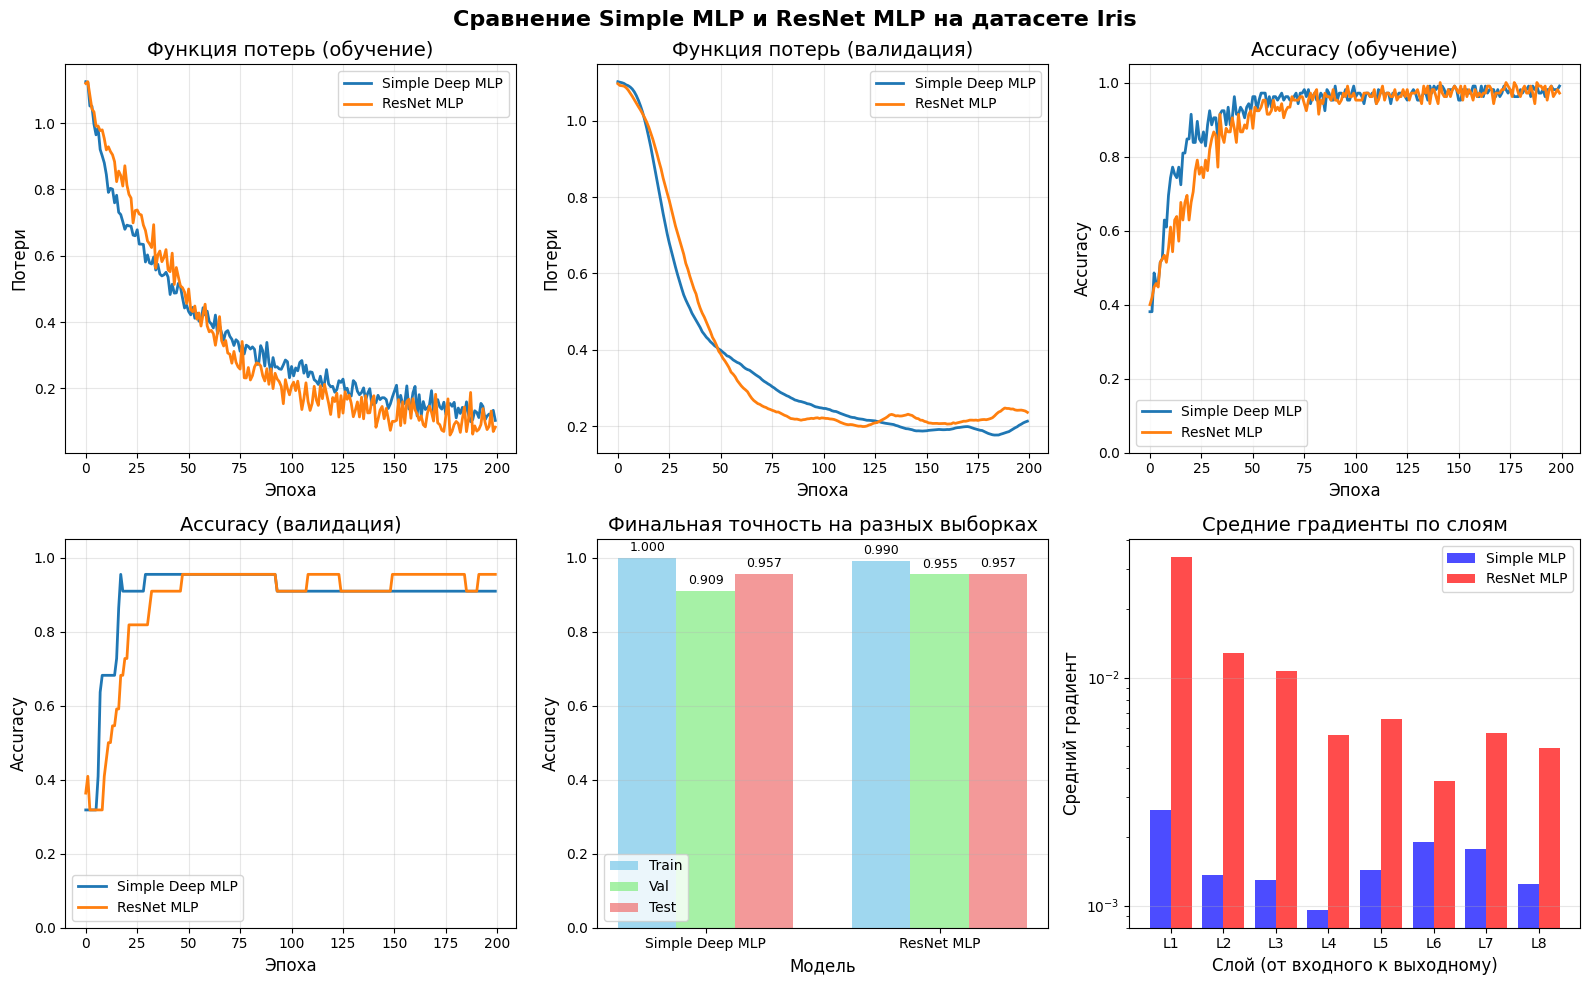

In [13]:
# 7. Визуализация результатов
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Сравнение Simple MLP и ResNet MLP на датасете Iris',
             fontsize=16, fontweight='bold')

# График 1: Потери при обучении
ax1 = axes[0, 0]
for result in results:
    ax1.plot(result['train_losses'], label=result['name'], linewidth=2)
ax1.set_xlabel('Эпоха', fontsize=12)
ax1.set_ylabel('Потери', fontsize=12)
ax1.set_title('Функция потерь (обучение)', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# График 2: Потери на валидации
ax2 = axes[0, 1]
for result in results:
    ax2.plot(result['val_losses'], label=result['name'], linewidth=2)
ax2.set_xlabel('Эпоха', fontsize=12)
ax2.set_ylabel('Потери', fontsize=12)
ax2.set_title('Функция потерь (валидация)', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

# График 3: Accuracy на обучении
ax3 = axes[0, 2]
for result in results:
    ax3.plot(result['train_accuracies'], label=result['name'], linewidth=2)
ax3.set_xlabel('Эпоха', fontsize=12)
ax3.set_ylabel('Accuracy', fontsize=12)
ax3.set_title('Accuracy (обучение)', fontsize=14)
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_ylim([0, 1.05])

# График 4: Accuracy на валидации
ax4 = axes[1, 0]
for result in results:
    ax4.plot(result['val_accuracies'], label=result['name'], linewidth=2)
ax4.set_xlabel('Эпоха', fontsize=12)
ax4.set_ylabel('Accuracy', fontsize=12)
ax4.set_title('Accuracy (валидация)', fontsize=14)
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_ylim([0, 1.05])

# График 5: Сравнение финальных accuracy
ax5 = axes[1, 1]
model_names = [r['name'] for r in results]
train_accs = [r['final_train_acc'] for r in results]
val_accs = [r['final_val_acc'] for r in results]
test_accs = [r.get('test_acc', 0) for r in results]

x = np.arange(len(model_names))
width = 0.25

bars1 = ax5.bar(x - width, train_accs, width, label='Train', alpha=0.8, color='skyblue')
bars2 = ax5.bar(x, val_accs, width, label='Val', alpha=0.8, color='lightgreen')
bars3 = ax5.bar(x + width, test_accs, width, label='Test', alpha=0.8, color='lightcoral')

ax5.set_xlabel('Модель', fontsize=12)
ax5.set_ylabel('Accuracy', fontsize=12)
ax5.set_title('Финальная точность на разных выборках', fontsize=14)
ax5.set_xticks(x)
ax5.set_xticklabels(model_names, rotation=0)
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')

# Добавим значения на столбцы
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# График 6: Градиенты (анализ проблемы исчезающих градиентов)
ax6 = axes[1, 2]

# Собираем средние градиенты по слоям
def get_average_gradients(model, X, y):
    """Вычисляет средние градиенты по слоям"""
    model.train()
    criterion = nn.CrossEntropyLoss()

    # Прямой проход
    output = model(X)
    loss = criterion(output, y)

    # Обратный проход
    model.zero_grad()
    loss.backward()

    # Собираем средние градиенты по слоям
    gradients = []
    layer_names = []

    for name, param in model.named_parameters():
        if 'weight' in name and param.grad is not None:
            gradients.append(param.grad.abs().mean().item())
            # Укорачиваем имя слоя для отображения
            short_name = name.replace('features.', '').replace('res_blocks.', '').replace('input_layer.', '')
            short_name = short_name[:20] + '...' if len(short_name) > 20 else short_name
            layer_names.append(short_name)

    return layer_names, gradients

# Получаем градиенты для обеих моделей
layer_names_simple, grads_simple = get_average_gradients(simple_mlp, X_train_tensor[:10], y_train_tensor[:10])
layer_names_res, grads_res = get_average_gradients(res_mlp, X_train_tensor[:10], y_train_tensor[:10])

# Отображаем только первые 8 слоев для наглядности
n_layers = min(8, len(grads_simple), len(grads_res))
x_indices = np.arange(n_layers)

ax6.bar(x_indices - 0.2, grads_simple[:n_layers], 0.4, label='Simple MLP', alpha=0.7, color='blue')
ax6.bar(x_indices + 0.2, grads_res[:n_layers], 0.4, label='ResNet MLP', alpha=0.7, color='red')

ax6.set_xlabel('Слой (от входного к выходному)', fontsize=12)
ax6.set_ylabel('Средний градиент', fontsize=12)
ax6.set_title('Средние градиенты по слоям', fontsize=14)
ax6.set_xticks(x_indices)
ax6.set_xticklabels([f'L{i+1}' for i in range(n_layers)])
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')
ax6.set_yscale('log')  # Логарифмическая шкала для наглядности

plt.tight_layout()
plt.show()



In [14]:
# 8. Таблица сравнения

comparison_data = []
for result in results:
    comparison_data.append({
        'Модель': result['name'],
        'Параметры': f"{sum(p.numel() for p in result['model'].parameters()):,}",
        'Train Acc': f"{result['final_train_acc']:.4f}",
        'Val Acc': f"{result['final_val_acc']:.4f}",
        'Test Acc': f"{result.get('test_acc', 0):.4f}",
        'Разница Train-Test': f"{abs(result['final_train_acc'] - result.get('test_acc', 0)):.4f}",
        'Стабильность*': f"{np.std(result['val_accuracies'][-20:]):.4f}"  # Стандартное отклонение последних 20 эпох
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df

,Модель,Параметры,Train Acc,Val Acc,Test Acc,Разница Train-Test,Стабильность*
0,Simple Deep MLP,"8,611",1.0000,0.9091,0.9565,0.0435,0.0000
1,ResNet MLP,"18,147",0.9905,0.9545,0.9565,0.0340,0.0208


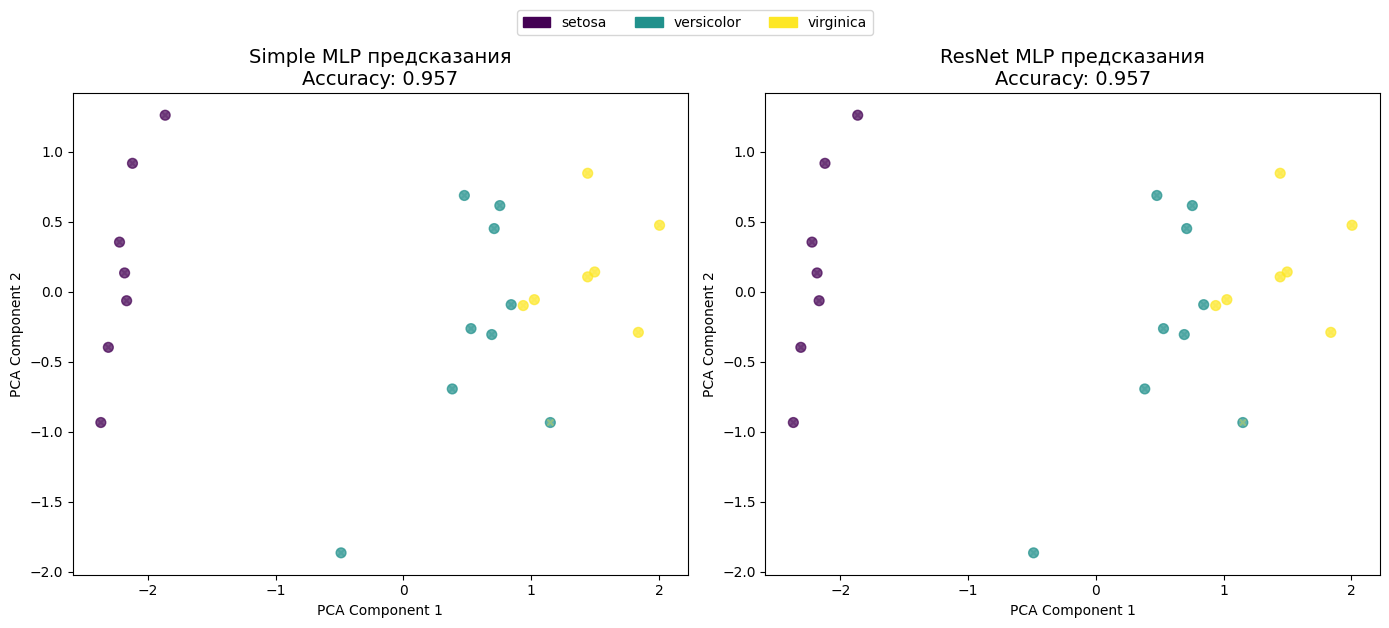

In [15]:
# 9. Дополнительный анализ: Визуализация предсказаний

fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Получаем предсказания обеих моделей
simple_mlp.eval()
res_mlp.eval()

with torch.no_grad():
    simple_pred = torch.max(simple_mlp(X_test_tensor), 1)[1].numpy()
    res_pred = torch.max(res_mlp(X_test_tensor), 1)[1].numpy()

# Визуализация в 2D (используем PCA для уменьшения размерности)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_test_2d = pca.fit_transform(X_test)

# График 1: Предсказания Simple MLP
scatter1 = ax1.scatter(X_test_2d[:, 0], X_test_2d[:, 1],
                      c=simple_pred, cmap='viridis', s=50, alpha=0.7)
ax1.scatter(X_test_2d[:, 0], X_test_2d[:, 1],
           c=y_test, cmap='viridis', s=20, alpha=0.3, marker='x')
ax1.set_title(f'Simple MLP предсказания\nAccuracy: {results_simple.get("test_acc", 0):.3f}', fontsize=14)
ax1.set_xlabel('PCA Component 1')
ax1.set_ylabel('PCA Component 2')

# График 2: Предсказания ResNet MLP
scatter2 = ax2.scatter(X_test_2d[:, 0], X_test_2d[:, 1],
                      c=res_pred, cmap='viridis', s=50, alpha=0.7)
ax2.scatter(X_test_2d[:, 0], X_test_2d[:, 1],
           c=y_test, cmap='viridis', s=20, alpha=0.3, marker='x')
ax2.set_title(f'ResNet MLP предсказания\nAccuracy: {results_res.get("test_acc", 0):.3f}', fontsize=14)
ax2.set_xlabel('PCA Component 1')
ax2.set_ylabel('PCA Component 2')

# Добавляем легенду для классов
import matplotlib.patches as mpatches
handles = []
for i, class_name in enumerate(iris.target_names):
    handles.append(mpatches.Patch(color=plt.cm.viridis(i/2), label=class_name))

fig2.legend(handles=handles, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.05))

plt.tight_layout()
plt.show()

